# Reduce and model *Kepler* observation of Spikey ala Hu+2020

In this notebook we used the dataset from Smith+2016: `lcwerrors_11606854.dat`. The goal of this exercise is to replicate the light curve reduction as in Hu+2020.

In [2]:
%load_ext autoreload
%autoreload 2

In [40]:
# Built-in
import sys
import copy

# Dependencies
import scipy
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from pathlib import Path
import jax
from jax import random
from jax import numpy as jnp
jax.config.update("jax_enable_x64", True)
import numpyro
import numpyro.distributions as dist
from numpyro.infer import NUTS, MCMC
# Select number of CPUs
numpyro.enable_x64()
numpyro.set_host_device_count(6)

# Internal methods
sys.path.append('../src')
from smbhb_jax import smbhb_jax
import smbhb as smbhb
import bayes as bs
import utils as ut
import plots as pt
pt.setup()

In [5]:
# Global paths
path = Path('../')
ddir = path / 'data'
rdir = path / 'results'

---
## 1. Create a normalized light curve
---

In [6]:
# Load Spikey model parameters (from Hu+2020)
params = smbhb.model_params()
params.sigma = 0

In [7]:
# Load and normalize light curve (from Smith+2018)
df = pd.read_csv(ddir / 'lcwerrors_11606854.dat', sep=' ', names=['time', 'flux', 'flux_err'])
med = df.flux.median()
df.flux /= med
df.flux_err /= med

# Convert to observer's frame (using z from Smith+2018)
df.time *= (1 + params.z)

# Cadence of observation (obserser's frame) [min]
# NOTE: the cadence changed during Kepler's operations so this is the median value:
print(f'Kepler cadence: {df.time.diff().median() * 3600:.1f} min')

Kepler cadence: 75.0 min


In [8]:
# Initialise model with parameters
model = smbhb.model(params)

# Generate model light curve and normalize
dm = model.light_curve(df.time.to_numpy(), df=True)
# dm.flux /= dm.flux.median()

# Normalize light curve to model
df.flux = df.flux * dm.flux.median() / df.flux.median()

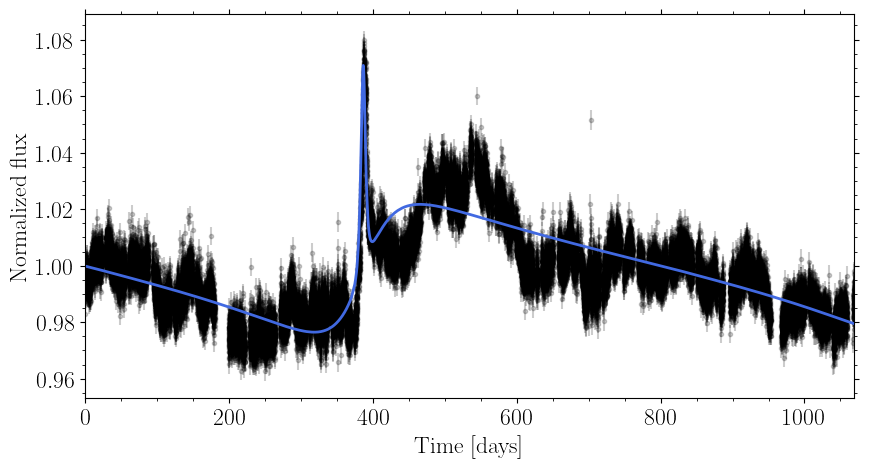

In [9]:
# Plot data and model
pt.plot_lc(df, dm, alpha=0.2);

In [10]:
# Save light curve
df.to_csv(path / 'data_spikey_QDM_kepler_smith2016.csv')

---
## 2. Create binned light curve ala Hu+2020
---

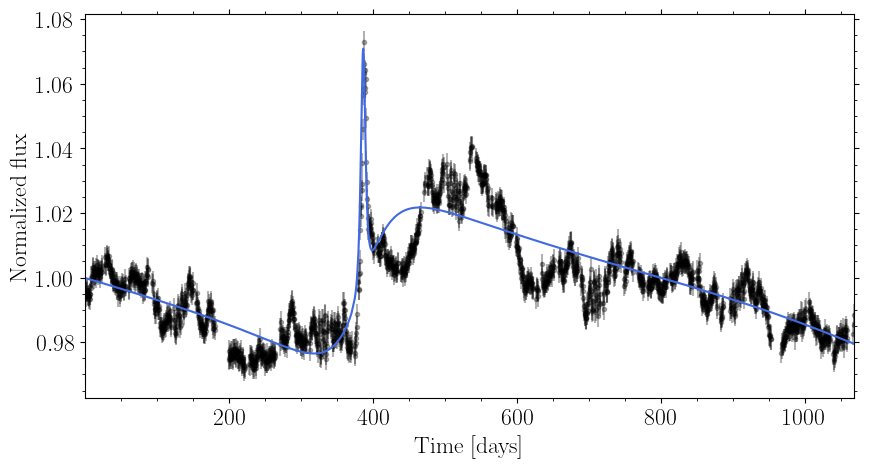

In [10]:
# Create a 0.5-d binned light curve and plot
df_bin_05d = ut.bin_lc(df, bin_size=0.5)
pt.plot_lc(df_bin_05d, dm, alpha=0.3);

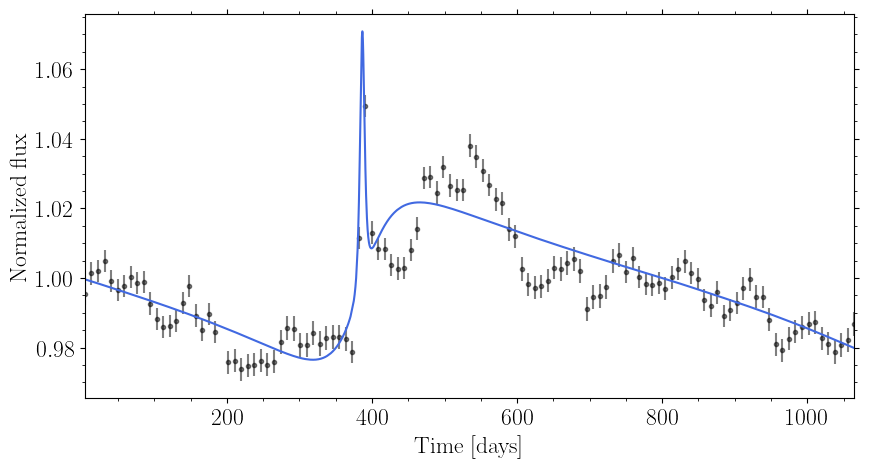

In [11]:
# Create a 9-d binned light curve and plot
df_bin_9d = ut.bin_lc(df, bin_size=9)
pt.plot_lc(df_bin_9d, dm, alpha=0.5);

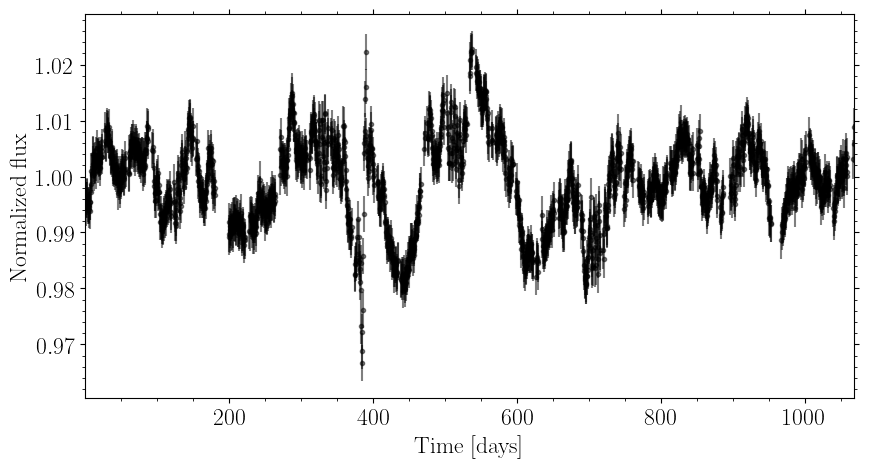

In [12]:
# Recover the Q-model using the DM-model from Hu+2020
df_Q = df.copy()
df_Q.flux = ((df_Q.flux - 1) - (dm.flux - 1)) + 1

# Bin DRW light curve
df_Q_bin_05d = ut.bin_lc(df_Q, bin_size=0.5)

# Plot light curve
pt.plot_lc(df_Q_bin_05d);

In [13]:
%%time

# Model DRW light curve with Gaussian processes and MCMC
time = df_Q_bin_05d.time.to_numpy()
flux = df_Q_bin_05d.flux.to_numpy()
flux_err = df_Q_bin_05d.flux_err.to_numpy()

# Define broad priors
priors = {
    'tau'  : dist.LogNormal(jnp.log(200.0), 1.0),
    'sigma': dist.LogNormal(jnp.log(jnp.std(flux)), 0.5),
    'mean' : dist.Normal(jnp.mean(flux), 0.5),
}

# Setup MCMC sampler
nuts_kernel = NUTS(
    bs.make_tinygp_model(priors=priors, build_kernel=bs.drw_kernel), 
    target_accept_prob=0.9, dense_mass=True, max_tree_depth=5)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=5000, num_chains=4, progress_bar=True, jit_model_args=True)

# Run MCMC analysis
rng_key = jax.random.PRNGKey(params.seed)
mcmc.run(rng_key, x=time, y=flux, yerr=flux_err, x_interp=time)
samples = mcmc.get_samples()
mcmc.print_summary()

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
      mean      1.00      0.00      1.00      0.99      1.00   7496.33      1.00
     sigma      0.01      0.00      0.01      0.01      0.01   5237.87      1.00
       tau     64.03     36.38     54.33     27.19    103.51   4637.94      1.00

Number of divergences: 0
CPU times: user 33min 19s, sys: 10.3 s, total: 33min 30s
Wall time: 5min 29s


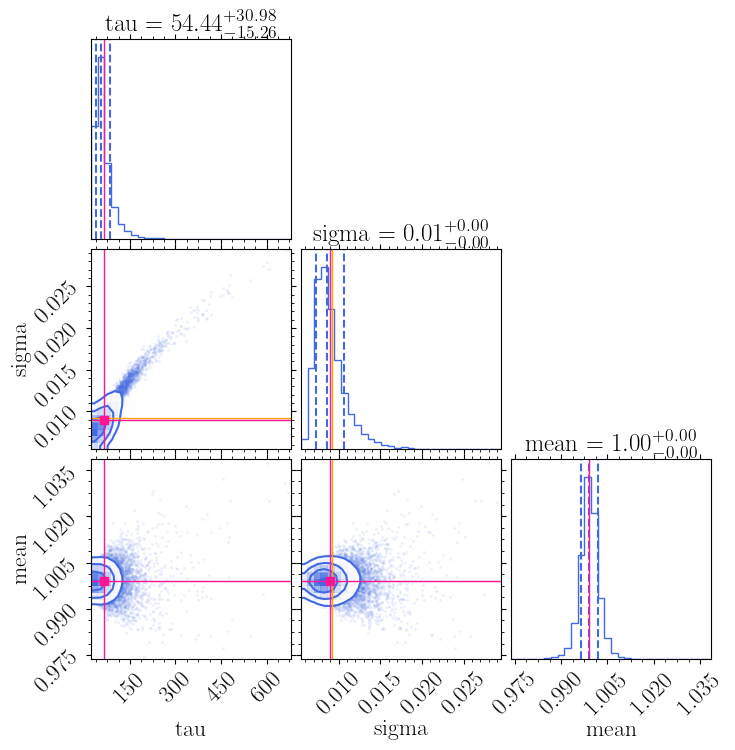

In [20]:
# Make corner plot
params = smbhb.model_params()
true_params = [1, params.sigma/1e3, params.tau]
pt.plot_corner_mcmc(samples, names=list(priors.keys()), true_params=true_params, bestfit='mean');

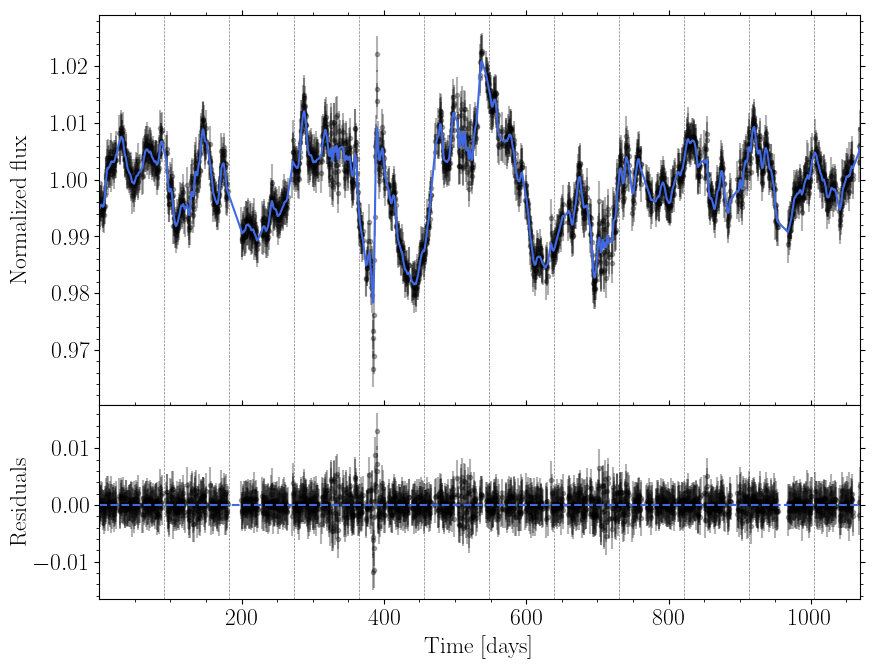

In [21]:
# Get DRW model and plot along with data
dm_Q_bin_05d = bs.get_drw_lc(df_Q_bin_05d.time, samples)
pt.plot_result(df_Q_bin_05d, dm_Q_bin_05d, alpha=0.3);

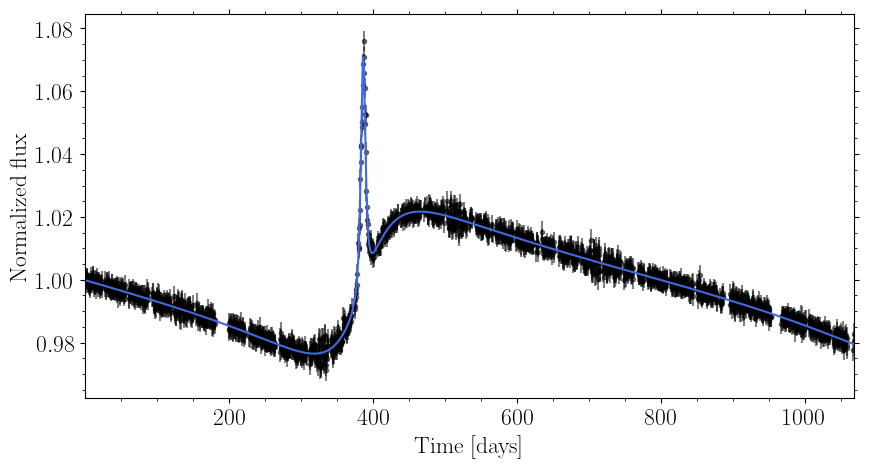

In [22]:
# Subtract the DRW model and plot
df_DM_bin_05d = df_bin_05d.copy()
df_DM_bin_05d.flux = ((df_DM_bin_05d.flux - 1) - (dm_Q_bin_05d.flux - 1)) + 1
pt.plot_lc(df_DM_bin_05d, dm);

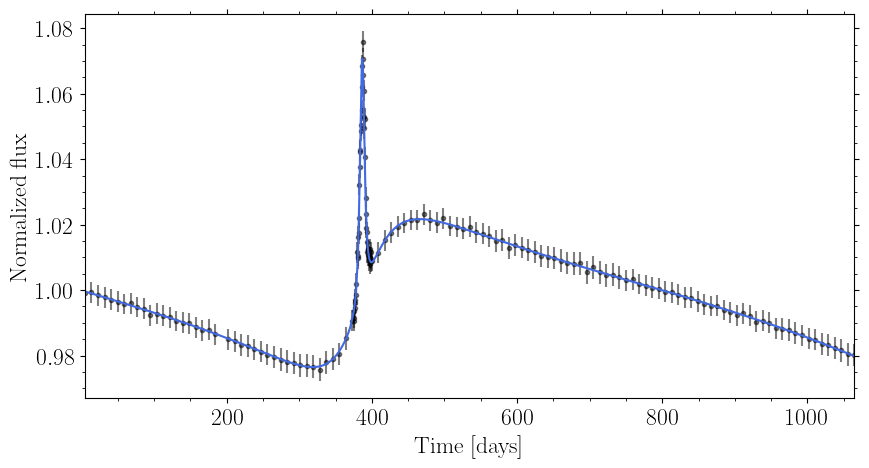

In [23]:
# Bin the DM to 9-d cadence light curve
df_DM_bin_9d = ut.bin_lc(df_DM_bin_05d, bin_size=9)

# Replace spike with 0.5-d cadence data
val0, val1 = 374, 400
df0 = df_DM_bin_9d[df_DM_bin_9d.time < val0]
df1 = df_DM_bin_05d[(df_DM_bin_05d.time > val0) & (df_DM_bin_05d.time < val1)]
df2 = df_DM_bin_9d[df_DM_bin_9d.time > val1]
df_hu = pd.concat([df0, df1, df2])

# Plot final light curve
pt.plot_lc(df_hu, dm);

In [24]:
# Save light curve
df_hu.to_csv(path / 'data_spikey_DM_kepler_hu2020.csv')

---
## 3. Model Spikey ala Hu+2020 with JAXNS
---

### 3.1. Use parameterisation {`logM1`, `logM2`}

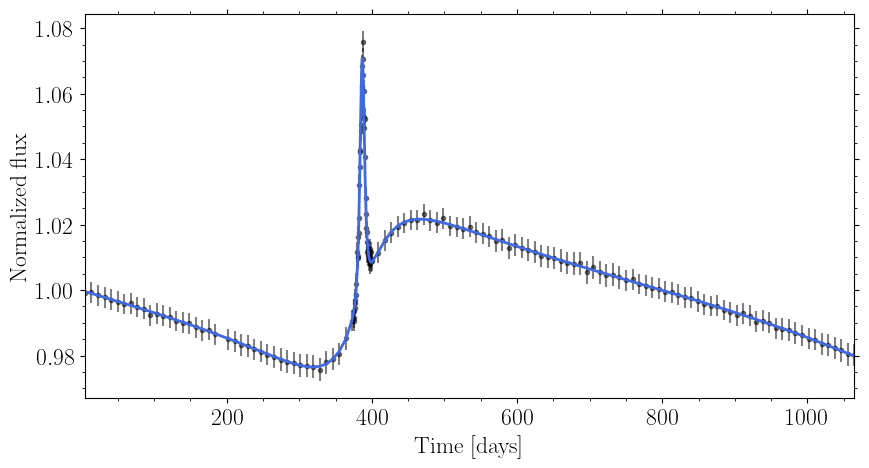

In [41]:
# Load Hu+2020 binned light curve of Spikey 
df = pd.read_csv(ddir / 'data_spikey_DM_kepler_hu2020.csv')
time = df.time.to_numpy()

# Generate relativistic Spikey model
params = smbhb.model_params()
params.sigma = 0 
model = smbhb.model(params)
dm = model.light_curve(time, df=True)

# Plot light curve
pt.plot_lc(df, dm, cm=c);

In [ ]:
# We use wide uninformative uniform priors
odir = rdir/'spikey_kepler_binhu_DM_jaxns'
priors = {
    'z'    : params.z,
    't0'   : dist.Uniform(0, 3),
    'P'    : dist.Uniform(0, 5),
    'i'    : dist.Uniform(0, 90),
    'e'    : dist.Uniform(0, 1),
    'w'    : dist.Uniform(0, 360),
    'logM1': dist.Uniform(5, 11),
    'logM2': dist.Uniform(5, 11),
    'alpha': dist.Uniform(-4, 4),
    'L'    : dist.Uniform(0, 1),
    'vz'   : params.vz,
}

In [ ]:
# %%time
# result = bs.run_jaxns(df, params, priors, bs.smbhb_mean_builder, ofile=odir/'result.npy')
result = ut.load_result(odir/'result.npy')

In [ ]:
# Show results
dm = smbhb.model_lightcurve(time, result['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm, cm=c, Q0=12, alpha=0.3)
fig = pt.plot_corner(result, best_params='mle', true_params=True, color=c);

In [ ]:
# Inspect the bimodality in w
clusters_w = bs.get_posterior_clusters(df, result, param_cluster='w', n_components=2)

In [ ]:
# Plot cluster with w0
result_w0 = clusters_w[0]
dm = smbhb.model_lightcurve(time, result_w0['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm, cm=c, Q0=12, alpha=0.3);
fig = pt.plot_corner(result_w0, best_params='mle', true_params=True, color=c);

In [ ]:
# # Plot cluster for w~260
result_w1 = clusters_w[1]
dm = smbhb.model_lightcurve(time, result_w1['likelihood']['mle'])
fig, ax = pt.plot_result(df, dm, cm=c, Q0=12, alpha=0.3);
fig = pt.plot_corner(result_w1, best_params='mle', true_params=True, color=c);

### 3.2. Use parameterisation {`logM`, `q`}